# customics — End-to-End Tutorial

This notebook walks through a complete **customics** workflow on the bundled toy dataset:

1. Load and explore multi-omics data  
2. Split into train / validation / test sets  
3. Configure and train a `CustOMICS` model  
4. Evaluate classification and survival performance  
5. Visualise the learned latent space  
6. Stratify patients by predicted risk (Kaplan-Meier)  
7. Explain model decisions with SHAP values  
8. Save and reload a trained model  

---

## Architecture at a glance

```
  protein  ──► AE_protein ──┐
                             │
  gene_exp ──► AE_gene   ──►─┤  Central VAE  ──► Classifier (tumour subtype)
                             │   (latent z)
  methyl   ──► AE_methyl ──┘               └──► Survival predictor (Cox)
```

**Phase 1** (epochs 0 → `switch`): each source autoencoder is trained
independently; task heads operate on per-source representations.  
**Phase 2** (epochs `switch` → end): the central VAE integrates all sources
into a unified latent space used by the task heads.

In [1]:
import logging
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split

from customics import CustOMICS, get_sub_omics_df, get_common_samples

# Show INFO-level logs from customics so we can see epoch progress.
logging.basicConfig(level=logging.INFO, format="%(message)s")

print(f"customics installed  ✓")
print(f"PyTorch version : {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Compute device  : {device}")

customics installed  ✓
PyTorch version : 2.11.0
Compute device  : cpu


---
## 1. Loading and Exploring the Data

The toy dataset contains **100 patients** with three omics modalities:

| Source | File | Features | Description |
|--------|------|----------|-------------|
| `protein` | `protein.txt` | 160 | Reverse Phase Protein Array (RPPA) |
| `gene_exp` | `gene_exp.txt` | 131 | RNA-seq gene expression |
| `methyl` | `methyl.txt` | 367 | DNA methylation (450K array) |

Clinical metadata provides a **tumour subtype label** (`cluster.id`, classes 1–5)
and synthetic survival columns added below.

> **Data format expected by customics:**  
> Each omics DataFrame must be indexed by **sample ID** (rows = samples, columns = features).  
> The clinical DataFrame must also be indexed by sample ID and contain the label,  
> event-indicator, and survival-time columns.

In [2]:
# Each omics file is features × samples; transpose so rows = samples, cols = features.
omics_df = {
    "protein":  pd.read_csv("toy_data/protein.txt",  sep="\t", index_col=0).T,
    "gene_exp": pd.read_csv("toy_data/gene_exp.txt", sep="\t", index_col=0).T,
    "methyl":   pd.read_csv("toy_data/methyl.txt",   sep="\t", index_col=0).T,
}

# Clinical metadata: index_col=1 puts the sample-ID column as the row index.
clinical_df = pd.read_csv("toy_data/labels.txt", sep="\t", index_col=1, header=0)

# The toy dataset has no real survival data, so we add synthetic columns here.
# In a real study, replace these with actual OS / OS.time values.
rng = np.random.default_rng(42)
clinical_df["OS"]      = rng.integers(0, 2,    size=len(clinical_df))   # 0 = censored, 1 = event
clinical_df["OS.time"] = rng.integers(200, 3000, size=len(clinical_df)) # days

print("Omics sources loaded:")
for name, df in omics_df.items():
    print(f"  {name:10s}  {df.shape[0]:>4d} samples × {df.shape[1]:>4d} features")
print(f"\nClinical data  : {clinical_df.shape[0]} rows × {clinical_df.shape[1]} columns")
print(f"Columns        : {clinical_df.columns.tolist()}")

Omics sources loaded:
  protein      100 samples ×  160 features
  gene_exp     100 samples ×  131 features
  methyl       100 samples ×  367 features

Clinical data  : 100 rows × 4 columns
Columns        : ['subjects', 'cluster.id', 'OS', 'OS.time']


=== protein (first 3 rows, first 4 features) ===


probe,ACC1,ACC_pS79,ACVRL1,Akt_pS473
subject1,-0.528421,-0.826949,2.465380,0.118108
subject2,-0.804377,-0.858630,2.679618,1.163897
subject3,0.596001,0.175652,2.782368,-1.550062



=== clinical_df (first 5 rows) ===


,subjects,cluster.id,OS,OS.time
subject1,1,5,0,2531
subject2,2,5,1,759
subject3,3,5,1,2453
subject4,4,3,0,220
subject5,5,5,0,2431



=== Label distribution (cluster.id) ===
cluster.id
1    35
2    13
3    19
4     8
5    25


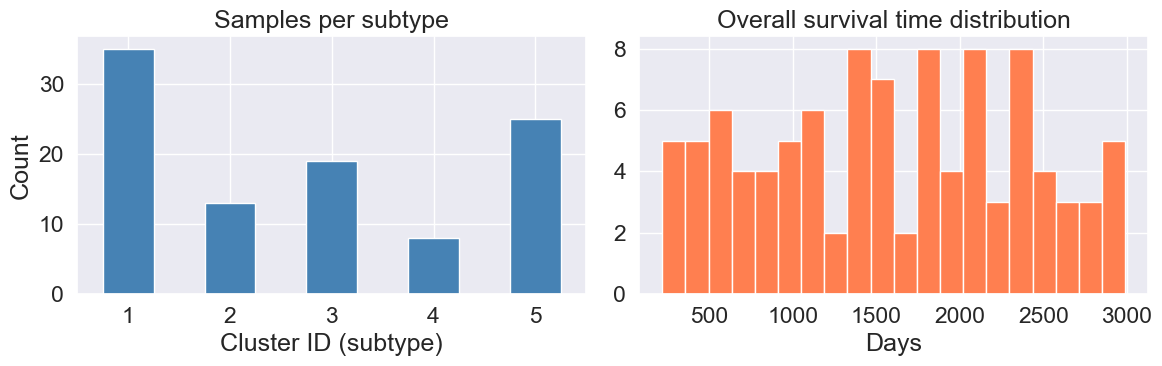

In [3]:
# Quick look at the protein matrix and clinical table.
print("=== protein (first 3 rows, first 4 features) ===")
display(omics_df["protein"].iloc[:3, :4])

print("\n=== clinical_df (first 5 rows) ===")
display(clinical_df.head())

# Class distribution — the label we will train the classifier on.
print("\n=== Label distribution (cluster.id) ===")
counts = clinical_df["cluster.id"].value_counts().sort_index()
print(counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Samples per subtype")
axes[0].set_xlabel("Cluster ID (subtype)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

clinical_df["OS.time"].hist(bins=20, ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Overall survival time distribution")
axes[1].set_xlabel("Days")
plt.tight_layout()
plt.show()

In [4]:
# get_common_samples returns the intersection of index values across all DataFrames.
# This ensures every downstream step uses exactly the same set of sample IDs.
lt_samples = get_common_samples(list(omics_df.values()) + [clinical_df])
print(f"Samples present in ALL sources and clinical data: {len(lt_samples)}")
print(f"First 5 sample IDs: {lt_samples[:5]}")

Samples present in ALL sources and clinical data: 100
First 5 sample IDs: ['subject1', 'subject10', 'subject100', 'subject11', 'subject12']


---
## 2. Splitting the Data

We split the full cohort into **train / validation / test** sets.  
`get_sub_omics_df` applies the same sample selection to all sources simultaneously,
keeping every dictionary in sync.

In [5]:
samples_train, samples_test = train_test_split(lt_samples, test_size=0.20, random_state=42)
samples_train, samples_val  = train_test_split(samples_train, test_size=0.15, random_state=42)

print(f"Train : {len(samples_train):>3d} samples")
print(f"Val   : {len(samples_val):>3d} samples")
print(f"Test  : {len(samples_test):>3d} samples")

Train :  68 samples
Val   :  12 samples
Test  :  20 samples


In [6]:
# get_sub_omics_df returns a new dict where each DataFrame is filtered to the given samples.
omics_train = get_sub_omics_df(omics_df, samples_train)
omics_val   = get_sub_omics_df(omics_df, samples_val)
omics_test  = get_sub_omics_df(omics_df, samples_test)

# Record input dimensions per source — used to configure the autoencoders below.
x_dim = {source: df.shape[1] for source, df in omics_df.items()}
print("Feature dimensions per source:", x_dim)

Feature dimensions per source: {'protein': 160, 'gene_exp': 131, 'methyl': 367}


---
## 3. Configuring the Model

`CustOMICS` is configured through five parameter dictionaries.
Each controls one component of the architecture.

### `source_params` — per-source autoencoders
One entry per omics modality.  The autoencoder compresses raw features into a
compact `latent_dim`-dimensional representation.

| Key | Type | Description |
|-----|------|-------------|
| `input_dim` | int | Number of input features (from the data) |
| `hidden_dim` | list[int] | Hidden layer sizes (encoder direction; decoder mirrors in reverse) |
| `latent_dim` | int | Per-source embedding dimension |
| `norm` | bool | Use BatchNorm after each FC layer |
| `dropout` | float | Dropout probability in [0, 1] |

### `central_params` — central VAE
Receives the concatenation of all per-source embeddings and produces the
shared latent code **z** used by both task heads.

| Key | Type | Description |
|-----|------|-------------|
| `hidden_dim` | list[int] | Hidden layer sizes |
| `latent_dim` | int | Dimension of **z** (the integrated representation) |
| `beta` | float | Weight of the MMD regularisation term |
| `norm` | bool | BatchNorm in layers |
| `dropout` | float | Dropout probability |

### `classif_params` — classifier head
Maps **z** → tumour subtype probabilities via a small MLP.

| Key | Type | Description |
|-----|------|-------------|
| `n_class` | int | Number of output classes |
| `lambda` | float | Classification loss weight in the total loss |
| `hidden_layers` | list[int] | MLP hidden sizes |
| `dropout` | float | Dropout probability |

### `surv_params` — Cox survival head
Maps **z** → log-hazard score.  Set `lambda = 0` to disable.

| Key | Type | Description |
|-----|------|-------------|
| `lambda` | float | Cox loss weight (`0` = disabled) |
| `dims` | list[int] | Hidden layer sizes (final output size is always 1) |
| `activation` | str | Activation name: `"SELU"`, `"ReLU"`, `"LeakyReLU"`, … |
| `l2_reg` | float | L2 regularisation on the survival head weights |
| `norm` | bool | BatchNorm in layers |
| `dropout` | float | Dropout probability |

### `train_params` — optimiser & phase schedule

| Key | Type | Description |
|-----|------|-------------|
| `switch` | int | Epoch where phase 1 ends and phase 2 begins |
| `lr` | float | Adam learning rate |

In [7]:
# ── Clinical column names ────────────────────────────────────────────────────
label     = "cluster.id"  # tumour subtype (1–5)
event     = "OS"          # event indicator: 1 = event occurred, 0 = censored
surv_time = "OS.time"     # time-to-event in days
task      = "classification"

# ── Training schedule ─────────────────────────────────────────────────────────
batch_size = 32
n_epochs   = 30   # 30 epochs is enough for the 100-sample toy dataset

# ── Per-source autoencoder parameters ────────────────────────────────────────
# x_dim is a dict {source_name: n_features}, computed from the data above.
# Using a dict comprehension keeps source_params in sync with x_dim automatically.
source_params = {
    source: {
        "input_dim":  x_dim[source],   # auto-filled — do not hardcode
        "hidden_dim": [256, 128],
        "latent_dim": 64,
        "norm":       True,
        "dropout":    0.2,
    }
    for source in x_dim
}

# ── Central VAE parameters ───────────────────────────────────────────────────
central_params = {
    "hidden_dim": [256, 128],
    "latent_dim": 64,   # dimension of the shared latent code z
    "norm":       True,
    "dropout":    0.2,
    "beta":       1.0,  # MMD regularisation weight
}

# ── Classifier head parameters ───────────────────────────────────────────────
classif_params = {
    "n_class":       5,     # subtypes 1-5
    "lambda":        5.0,   # classification loss weight
    "hidden_layers": [64, 32],
    "dropout":       0.2,
}

# ── Survival head parameters ─────────────────────────────────────────────────
# lambda=0 disables the Cox loss; the survival head is still built but not trained.
# To enable survival, set lambda > 0 and ensure OS / OS.time contain real data.
surv_params = {
    "lambda":     0.0,
    "dims":       [32, 16],
    "activation": "SELU",
    "l2_reg":     1e-2,
    "norm":       True,
    "dropout":    0.2,
}

# ── Optimiser & phase schedule ───────────────────────────────────────────────
# switch=15 means:
#   epochs 0–14  → Phase 1: source AEs train independently
#   epochs 15–29 → Phase 2: central VAE takes over, heads are jointly optimised
train_params = {"switch": 15, "lr": 1e-3}

print("source_params keys :", list(source_params.keys()))
print("input dimensions   :", {k: v["input_dim"] for k, v in source_params.items()})
print("central latent dim :", central_params["latent_dim"])
print(f"training phases    : phase 1 → epochs 0–{train_params['switch']-1}, "
      f"phase 2 → epochs {train_params['switch']}–{n_epochs-1}")

source_params keys : ['protein', 'gene_exp', 'methyl']
input dimensions   : {'protein': 160, 'gene_exp': 131, 'methyl': 367}
central latent dim : 64
training phases    : phase 1 → epochs 0–14, phase 2 → epochs 15–29


---
## 4. Building and Training the Model

### Model instantiation

Pass the five config dicts to `CustOMICS`.  The model is built immediately but
weights are random until `fit()` is called.

In [8]:
model = CustOMICS(
    source_params  = source_params,
    central_params = central_params,
    classif_params = classif_params,
    surv_params    = surv_params,
    train_params   = train_params,
    device         = device,
)
print(f"Total trainable parameters: {model.get_number_parameters():,}")

Total trainable parameters: 790,778


In [9]:
# fit() returns self, so it can be chained.
# omics_val triggers validation loss logging after each epoch.
model.fit(
    omics_train = omics_train,
    clinical_df = clinical_df,
    label       = label,
    event       = event,
    surv_time   = surv_time,
    omics_val   = omics_val,
    batch_size  = batch_size,
    n_epochs    = n_epochs,
    verbose     = True,
)

Epoch 1/30 | train=30.0656 | val=32.6000
Epoch 2/30 | train=21.0603 | val=29.5567
Epoch 3/30 | train=21.6399 | val=24.0390
Epoch 4/30 | train=16.7678 | val=20.3637
Epoch 5/30 | train=14.2702 | val=17.3006
Epoch 6/30 | train=11.6989 | val=15.2691
Epoch 7/30 | train=10.7229 | val=14.1661
Epoch 8/30 | train=12.8137 | val=12.2988
Epoch 9/30 | train=8.8239 | val=12.3560
Epoch 10/30 | train=8.1081 | val=11.8508
Epoch 11/30 | train=7.5135 | val=11.2439
Epoch 12/30 | train=10.0255 | val=10.3000
Epoch 13/30 | train=11.1363 | val=7.9571
Epoch 14/30 | train=9.8757 | val=8.1474
Epoch 15/30 | train=7.8682 | val=8.3471
Epoch 16/30 | train=8.5299 | val=8.7541
Epoch 17/30 | train=4.1771 | val=6.8581
Epoch 18/30 | train=3.9224 | val=5.8396
Epoch 19/30 | train=4.2187 | val=5.2492
Epoch 20/30 | train=2.9594 | val=4.8492
Epoch 21/30 | train=4.3312 | val=4.4094
Epoch 22/30 | train=2.7746 | val=4.1800
Epoch 23/30 | train=4.3299 | val=4.0494
Epoch 24/30 | train=2.8023 | val=3.9678
Epoch 25/30 | train=4.6482 

CustOMICS(
  (autoencoders): ModuleList(
    (0): AutoEncoder(
      (encoder): Encoder(
        (net): Sequential(
          (InputLayer): FullyConnectedLayer(
            (fc_block): Sequential(
              (0): Linear(in_features=160, out_features=256, bias=True)
              (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): Dropout(p=0.2, inplace=False)
              (3): LeakyReLU(negative_slope=0.2, inplace=True)
            )
          )
          (Layer1): FullyConnectedLayer(
            (fc_block): Sequential(
              (0): Linear(in_features=256, out_features=128, bias=True)
              (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): LeakyReLU(negative_slope=0.2, inplace=True)
            )
          )
          (OutputLayer): FullyConnectedLayer(
            (fc_block): Sequential(
              (0): Linear(in_features=128, out_features=64, bias=True)
  

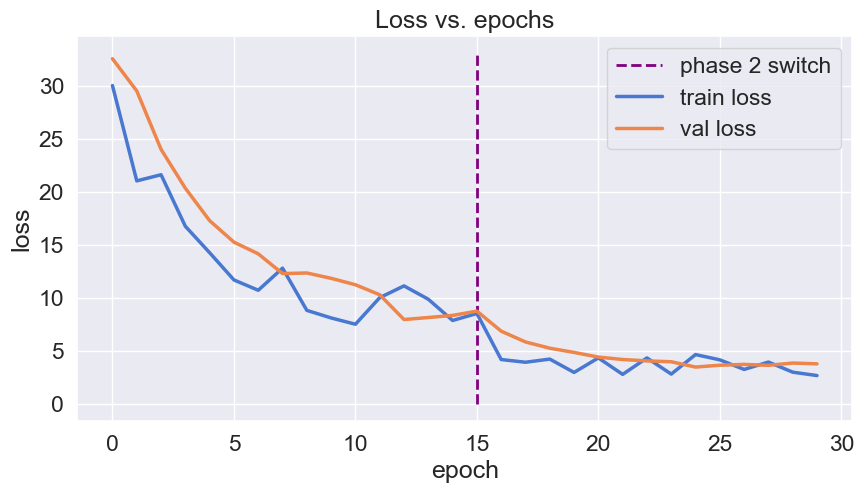

In [10]:
# Plot the train/validation loss curves to check for overfitting.
# The vertical dashed line marks the phase 1 → phase 2 transition.
model.plot_loss()

---
## 5. Evaluating the Model

`evaluate()` runs inference on the held-out **test set** and returns a metrics dict.

- **Classification** (`task="classification"`): accuracy, macro F1, weighted F1,
  and per-class ROC-AUC.  
- **Survival** (`task="survival"`): concordance index (C-index) via the Cox head.

> Set `plot_roc=True` to overlay per-class ROC curves on a single figure.


── Classification metrics on the test set ──
  Accuracy                 : 1.0000
  F1-score                 : 1.0000
  Precision                : 1.0000
  Recall                   : 1.0000
  AUC                      : 1.0000


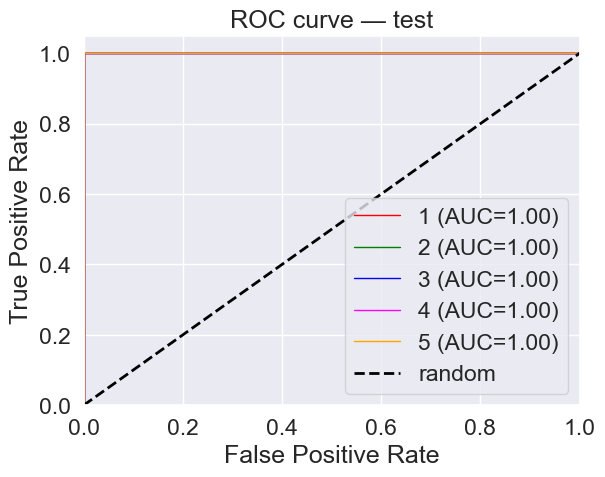

In [11]:
# Evaluate tumour-subtype classification on the test split.
metrics = model.evaluate(
    omics_test  = omics_test,
    clinical_df = clinical_df,
    label       = label,
    event       = event,
    surv_time   = surv_time,
    task        = "classification",
    batch_size  = 1024,
    plot_roc    = True,
)

print("\n── Classification metrics on the test set ──")
for k, v in metrics.items():
    print(f"  {k:<25s}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

In [15]:
# Evaluate the Cox survival head on the test split.
# With synthetic OS/OS.time the C-index will be ~0.5 (random), which is expected.
# Replace OS/OS.time with real data to obtain meaningful survival performance.
surv_metrics = model.evaluate(
    omics_test  = omics_test,
    clinical_df = clinical_df,
    label       = label,
    event       = event,
    surv_time   = surv_time,
    task        = "survival",
    batch_size  = 1024,
)

print("\n── Survival metrics on the test set ──")
print("C-index :", surv_metrics)


── Survival metrics on the test set ──
C-index : 0.46808510638297873


---
## 6. Visualising the Latent Space

`get_latent_representation()` encodes every sample in `omics_df` through the
trained central VAE and returns a NumPy array of shape `(n_samples, latent_dim)`.

`plot_representation()` runs t-SNE on that array and colours each point by the
clinical label — a quick sanity check that the model has learned subtype-discriminative
features.

Latent space shape: (100, 64)  (n_samples × latent_dim)


/opt/anaconda3/envs/bc_multiomics/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


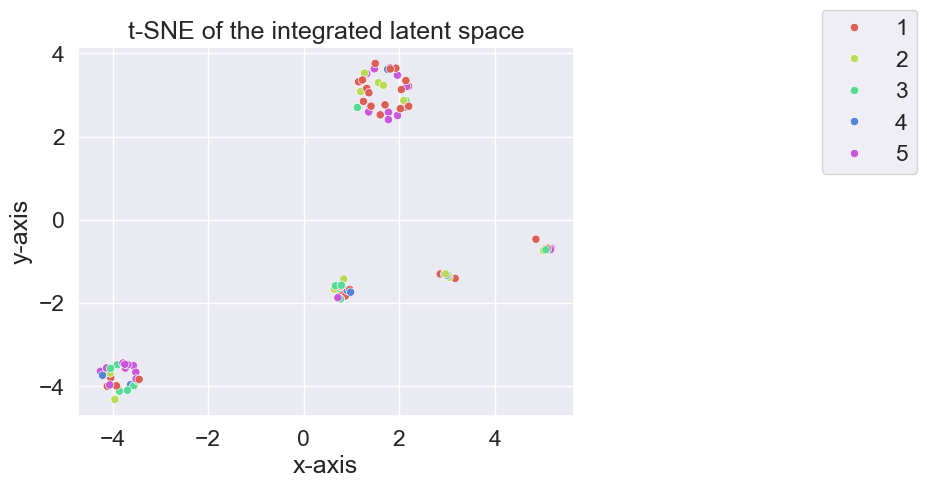

<Figure size 640x480 with 0 Axes>

In [16]:
# Get the latent embedding for ALL samples (train + val + test combined).
z = model.get_latent_representation(omics_df)
print(f"Latent space shape: {z.shape}  (n_samples × latent_dim)")

# Create the results directory if it doesn't exist yet.
os.makedirs("results", exist_ok=True)

model.plot_representation(
    omics_df    = omics_df,
    clinical_df = clinical_df,
    label       = label,
    filename    = "results/latent_representation",
    title       = "t-SNE of the integrated latent space",
    show        = True,
)

---
## 7. Survival Risk Stratification

`stratify()` uses the Cox head to assign each sample a risk score, then splits
the cohort into high-risk / low-risk groups at the median score and draws a
Kaplan-Meier curve.

> **Note:** with synthetic survival data the curves will overlap.  
> This section shows the API; meaningful separation requires real OS/OS.time.

In [17]:
model.stratify(
    omics_df    = omics_df,
    clinical_df = clinical_df,
    event       = event,
    surv_time   = surv_time,
    filename    = "results/km_stratification",
    show        = True,
)

TypeError: CustOMICS.stratify() got an unexpected keyword argument 'filename'

---
## 8. Feature Importance with SHAP

`explain()` uses `shap.DeepExplainer` to compute feature-attribution values for
one omics source and one tumour subtype.

**Parameters:**

| Parameter | Description |
|-----------|-------------|
| `sample_id` | List of sample IDs to explain |
| `omics_df` | Full omics dictionary |
| `clinical_df` | Clinical metadata |
| `source` | Which omics source to explain (`"gene_exp"`, `"protein"`, `"methyl"`) |
| `subtype` | Integer label of the class to explain (1-based here) |
| `label` | Column in `clinical_df` containing the class labels |
| `device` | `"cpu"` or `"cuda"` |
| `show` | Display the SHAP summary plot inline |

The bar plot shows the **mean absolute SHAP value** for each feature — higher
means more influential for predicting the chosen subtype.

In [ ]:
# Feature importance for gene expression → subtype 1
model.explain(
    sample_id   = lt_samples,
    omics_df    = omics_df,
    clinical_df = clinical_df,
    source      = "gene_exp",
    subtype     = 1,
    label       = label,
    device      = "cpu",
    show        = True,
)

In [ ]:
# Feature importance for protein expression → subtype 1
model.explain(
    sample_id   = lt_samples,
    omics_df    = omics_df,
    clinical_df = clinical_df,
    source      = "protein",
    subtype     = 1,
    label       = label,
    device      = "cpu",
    show        = True,
)

In [ ]:
# Feature importance for DNA methylation → subtype 1
model.explain(
    sample_id   = lt_samples,
    omics_df    = omics_df,
    clinical_df = clinical_df,
    source      = "methyl",
    subtype     = 1,
    label       = label,
    device      = "cpu",
    show        = True,
)

---
## 9. Saving and Reloading the Model

`CustOMICS` uses PyTorch's standard `state_dict` / `load_state_dict` mechanism.
The helper methods `save()` and `load()` wrap this pattern so you don't need to
worry about the architecture parameters — `load()` reconstructs the full model
from the checkpoint.

> **Best practice:** save after the final training run so you can reproduce
> predictions without retraining.

In [ ]:
import torch

os.makedirs("results", exist_ok=True)
checkpoint_path = "results/customics_model.pt"

# save() stores both the architecture config and the weight tensors.
model.save(checkpoint_path)
print(f"Model saved to: {checkpoint_path}")

In [ ]:
# load() is a class method — it rebuilds the model from the checkpoint file.
loaded_model = CustOMICS.load(checkpoint_path, device=device)
print(f"Model loaded from: {checkpoint_path}")
print(f"Parameters in loaded model: {loaded_model.get_number_parameters():,}")

In [ ]:
# Sanity-check: predictions from the reloaded model should match the originals.
metrics_reloaded = loaded_model.evaluate(
    omics_test  = omics_test,
    clinical_df = clinical_df,
    label       = label,
    event       = event,
    surv_time   = surv_time,
    task        = "classification",
    batch_size  = 1024,
    plot_roc    = False,
)
print("\n── Reloaded model — classification metrics ──")
for k, v in metrics_reloaded.items():
    print(f"  {k:<25s}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")